# **Fuzzy Inference System (FIS)**

In [ ]:

!pip install scikit-fuzzy

import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess the dataset
print("INDIAN LIVER PATIENT DATASET ANALYSIS")


# Download the dataset
import os
file_name = 'Indian Liver Patient Dataset (ILPD).csv'
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00225/Indian%20Liver%20Patient%20Dataset%20(ILPD).csv'

if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    !wget -q {dataset_url} -O "{file_name}"
    print("Download complete.")
else:
    print(f"{file_name} already exists. Skipping download.")

# Load the dataset
df = pd.read_csv(file_name)

# Display basic information
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values (if any)
df = df.dropna()

# Encode categorical variables (Gender)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

# Separate features and target
# Assuming the last column is the target (Dataset column)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Convert target to binary (1 = Liver Patient, 0 = Normal)
y = np.where(y == 1, 1, 0)

# Get feature names
feature_names = df.columns[:-1].tolist()
print("\nFeatures:", feature_names)
print("Target distribution:")
print(pd.Series(y).value_counts())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

INDIAN LIVER PATIENT DATASET ANALYSIS
Indian Liver Patient Dataset (ILPD).csv already exists. Skipping download.

Dataset Shape: (583, 11)

First 5 rows:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sgot   TP  ALB   A/G  Sickness
0   65  Female   0.7  0.1      187    16    18  6.8  3.3  0.90         1
1   62    Male  10.9  5.5      699    64   100  7.5  3.2  0.74         1
2   62    Male   7.3  4.1      490    60    68  7.0  3.3  0.89         1
3   58    Male   1.0  0.4      182    14    20  6.8  3.4  1.00         1
4   72    Male   3.9  2.0      195    27    59  7.3  2.4  0.40         1

Missing Values:
Age         0
Gender      0
TB          0
DB          0
Alkphos     0
Sgpt        0
Sgot        0
TP          0
ALB         0
A/G         4
Sickness    0
dtype: int64

Features: ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G']
Target distribution:
1    414
0    165
Name: count, dtype: int64

Training set size: 463
Test set size: 116


**Fuzzy Inference System for Liver Disease Prediction**

FUZZY INFERENCE SYSTEM FOR LIVER DISEASE PREDICTION


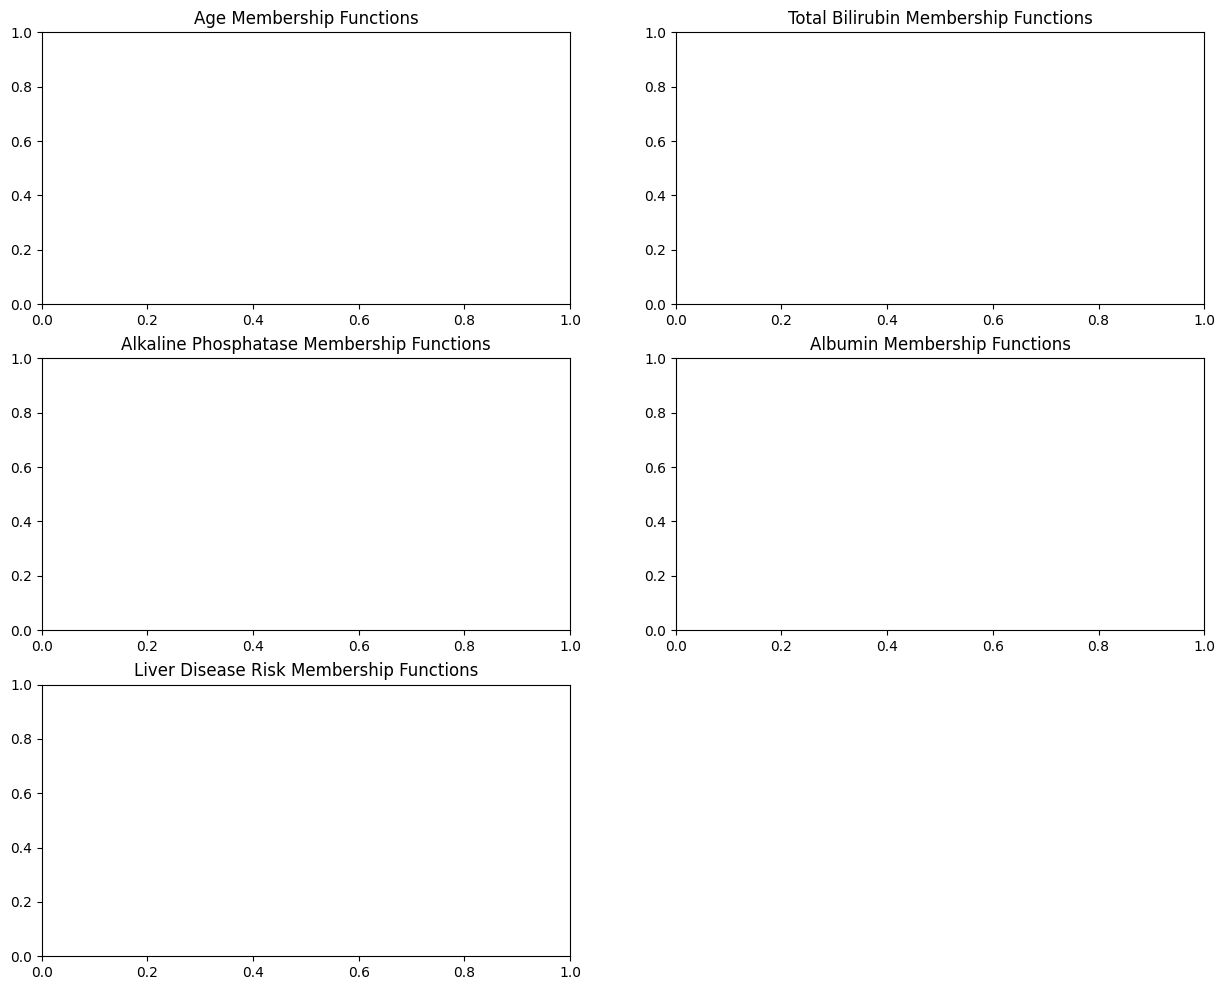

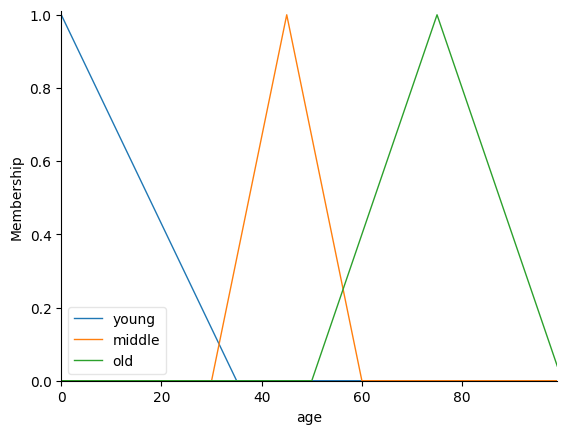

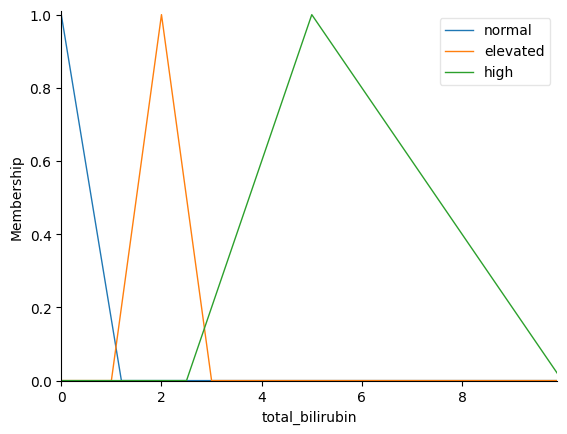

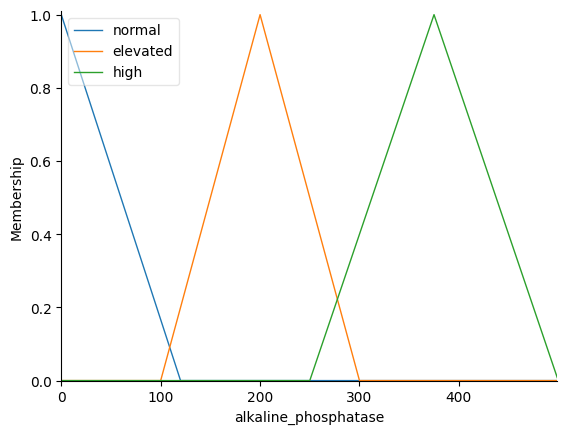

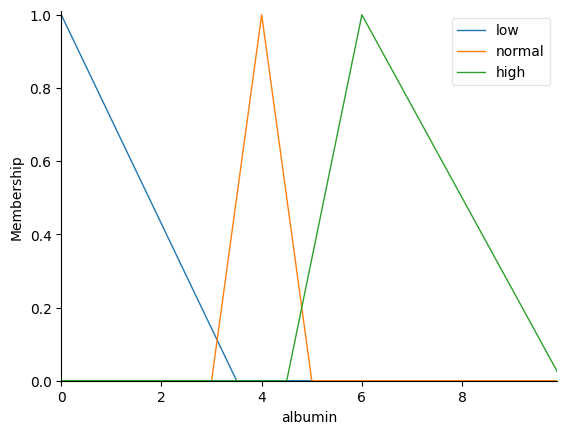

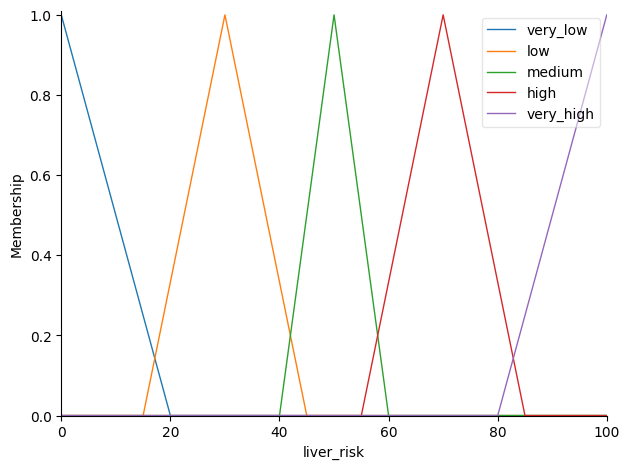


FIS Test on Sample Patients:
Patient 1:
  Age: 783.8, TB: 0.77, ALP: 379603.7, Alb: 115684.35
  Risk Score: 70.00%
  FIS Prediction: Liver Disease
  Actual: Liver Disease
  ✓ Correct
----------------------------------------
Patient 11:
  Age: 389.4, TB: 1.19, ALP: 93280.3, Alb: 113196.36
  Risk Score: 54.57%
  FIS Prediction: Liver Disease
  Actual: Liver Disease
  ✓ Correct
----------------------------------------
Patient 21:
  Age: 734.5, TB: 0.77, ALP: 39931.2, Alb: 24533.32
  Risk Score: 70.00%
  FIS Prediction: Liver Disease
  Actual: Liver Disease
  ✓ Correct
----------------------------------------
Patient 31:
  Age: 866.0, TB: 1.19, ALP: 43112.6, Alb: 4403.19
  Risk Score: 54.57%
  FIS Prediction: Liver Disease
  Actual: Normal
  ✗ Incorrect
----------------------------------------
Patient 41:
  Age: 619.5, TB: 1.19, ALP: 26716.3, Alb: 142599.91
  Risk Score: 54.57%
  FIS Prediction: Liver Disease
  Actual: Liver Disease
  ✓ Correct
----------------------------------------


In [ ]:
#FUZZY INFERENCE SYSTEM

print("FUZZY INFERENCE SYSTEM FOR LIVER DISEASE PREDICTION")

# Since we have many features, we'll select the most important ones for FIS
# Based on medical importance: Age, Total Bilirubin, Direct Bilirubin, Alkaline Phosphatase, Albumin

#  Define Linguistic Variables
# Input variables (selected key features)
age = ctrl.Antecedent(np.arange(0, 100, 1), 'age')
total_bilirubin = ctrl.Antecedent(np.arange(0, 10, 0.1), 'total_bilirubin')
alkaline_phosphatase = ctrl.Antecedent(np.arange(0, 500, 1), 'alkaline_phosphatase')
albumin = ctrl.Antecedent(np.arange(0, 10, 0.1), 'albumin')

# Output variable (Liver Disease Risk)
liver_risk = ctrl.Consequent(np.arange(0, 101, 1), 'liver_risk')

# Construct Membership Functions
# Age membership functions
age['young'] = fuzz.trimf(age.universe, [0, 0, 35])
age['middle'] = fuzz.trimf(age.universe, [30, 45, 60])
age['old'] = fuzz.trimf(age.universe, [50, 75, 100])

# Total Bilirubin (normal range: 0.3-1.2 mg/dL)
total_bilirubin['normal'] = fuzz.trimf(total_bilirubin.universe, [0, 0, 1.2])
total_bilirubin['elevated'] = fuzz.trimf(total_bilirubin.universe, [1.0, 2.0, 3.0])
total_bilirubin['high'] = fuzz.trimf(total_bilirubin.universe, [2.5, 5, 10])

# Alkaline Phosphatase (normal range: 30-120 U/L)
alkaline_phosphatase['normal'] = fuzz.trimf(alkaline_phosphatase.universe, [0, 0, 120])
alkaline_phosphatase['elevated'] = fuzz.trimf(alkaline_phosphatase.universe, [100, 200, 300])
alkaline_phosphatase['high'] = fuzz.trimf(alkaline_phosphatase.universe, [250, 375, 500])

# Albumin (normal range: 3.5-5.0 g/dL)
albumin['low'] = fuzz.trimf(albumin.universe, [0, 0, 3.5])
albumin['normal'] = fuzz.trimf(albumin.universe, [3.0, 4.0, 5.0])
albumin['high'] = fuzz.trimf(albumin.universe, [4.5, 6, 10])

# Output - Liver Disease Risk
liver_risk['very_low'] = fuzz.trimf(liver_risk.universe, [0, 0, 20])
liver_risk['low'] = fuzz.trimf(liver_risk.universe, [15, 30, 45])
liver_risk['medium'] = fuzz.trimf(liver_risk.universe, [40, 50, 60])
liver_risk['high'] = fuzz.trimf(liver_risk.universe, [55, 70, 85])
liver_risk['very_high'] = fuzz.trimf(liver_risk.universe, [80, 100, 100])

# Visualize membership functions
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Age
age.view(ax=axes[0, 0])
axes[0, 0].set_title('Age Membership Functions')

# Total Bilirubin
total_bilirubin.view(ax=axes[0, 1])
axes[0, 1].set_title('Total Bilirubin Membership Functions')

# Alkaline Phosphatase
alkaline_phosphatase.view(ax=axes[1, 0])
axes[1, 0].set_title('Alkaline Phosphatase Membership Functions')

# Albumin
albumin.view(ax=axes[1, 1])
axes[1, 1].set_title('Albumin Membership Functions')

# Liver Risk
liver_risk.view(ax=axes[2, 0])
axes[2, 0].set_title('Liver Disease Risk Membership Functions')

# Hide empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

# Build the Knowledge Base (Rules)
rules = []

# Rule 1: IF age is young AND all tests normal THEN risk is very_low
rules.append(ctrl.Rule(
    age['young'] & total_bilirubin['normal'] & alkaline_phosphatase['normal'] & albumin['normal'],
    liver_risk['very_low']
))

# Rule 2: IF age is middle with slightly elevated bilirubin THEN risk is low
rules.append(ctrl.Rule(
    age['middle'] & total_bilirubin['elevated'] & alkaline_phosphatase['normal'] & albumin['normal'],
    liver_risk['low']
))

# Rule 3: IF bilirubin is elevated and alkaline phosphatase is elevated THEN risk is medium
rules.append(ctrl.Rule(
    total_bilirubin['elevated'] & alkaline_phosphatase['elevated'] & albumin['normal'],
    liver_risk['medium']
))

# Rule 4: IF bilirubin is high and albumin is low THEN risk is high
rules.append(ctrl.Rule(
    total_bilirubin['high'] & albumin['low'],
    liver_risk['high']
))

# Rule 5: IF all indicators are abnormal THEN risk is very_high
rules.append(ctrl.Rule(
    total_bilirubin['high'] & alkaline_phosphatase['high'] & albumin['low'],
    liver_risk['very_high']
))

# Rule 6: IF age is old with elevated bilirubin THEN risk is medium
rules.append(ctrl.Rule(
    age['old'] & total_bilirubin['elevated'],
    liver_risk['medium']
))

# Rule 7: IF alkaline phosphatase is high regardless of other factors THEN risk is high
rules.append(ctrl.Rule(
    alkaline_phosphatase['high'],
    liver_risk['high']
))

# Rule 8: IF albumin is low and age is old THEN risk is high
rules.append(ctrl.Rule(
    albumin['low'] & age['old'],
    liver_risk['high']
))

# Create Control System
liver_ctrl = ctrl.ControlSystem(rules)
liver_simulation = ctrl.ControlSystemSimulation(liver_ctrl)

# Test the FIS on sample data
print("\nFIS Test on Sample Patients:")

# Select a few test samples
sample_indices = [0, 10, 20, 30, 40]
for idx in sample_indices[:len(X_test)]:
    patient_data = X_test[idx]
    actual = y_test[idx]

    # Map scaled values back to original ranges for FIS
    age_val = patient_data[0] * scaler.scale_[0] + scaler.mean_[0]  # Denormalize age
    tb_val = patient_data[1] * scaler.scale_[1] + scaler.mean_[1]  # Denormalize total bilirubin
    alp_val = patient_data[4] * scaler.scale_[4] + scaler.mean_[4]  # Denormalize alkaline phosphatase
    alb_val = patient_data[6] * scaler.scale_[6] + scaler.mean_[6]  # Denormalize albumin

    try:
        liver_simulation.input['age'] = age_val
        liver_simulation.input['total_bilirubin'] = abs(tb_val)  # Ensure positive
        liver_simulation.input['alkaline_phosphatase'] = abs(alp_val)
        liver_simulation.input['albumin'] = abs(alb_val)

        liver_simulation.compute()

        risk_score = liver_simulation.output['liver_risk']
        prediction = 1 if risk_score > 50 else 0  # Threshold at 50%

        print(f"Patient {idx+1}:")
        print(f"  Age: {age_val:.1f}, TB: {tb_val:.2f}, ALP: {alp_val:.1f}, Alb: {alb_val:.2f}")
        print(f"  Risk Score: {risk_score:.2f}%")
        print(f"  FIS Prediction: {'Liver Disease' if prediction == 1 else 'Normal'}")
        print(f"  Actual: {'Liver Disease' if actual == 1 else 'Normal'}")
        print(f"  {'✓ Correct' if prediction == actual else '✗ Incorrect'}")
        print("-" * 40)
    except:
        print(f"Patient {idx+1}: Could not compute (values out of range)")

**ANFIS for Liver Disease Prediction**

ANFIS FOR LIVER DISEASE PREDICTION

ANFIS Training Data Shape: (370, 4)
ANFIS Validation Data Shape: (93, 4)
ANFIS Test Data Shape: (116, 4)

Training ANFIS model...
Epoch 0: Train Loss=0.702719, Train Acc=0.4297, Val Loss=110053412.199441, Val Acc=0.6129
Epoch 20: Train Loss=0.178575, Train Acc=0.7189, Val Loss=0.182266, Val Acc=0.7849
Epoch 40: Train Loss=0.178576, Train Acc=0.7189, Val Loss=0.182255, Val Acc=0.7849
Epoch 60: Train Loss=0.178575, Train Acc=0.7189, Val Loss=0.182273, Val Acc=0.7849
Epoch 80: Train Loss=0.178575, Train Acc=0.7189, Val Loss=0.182257, Val Acc=0.7849


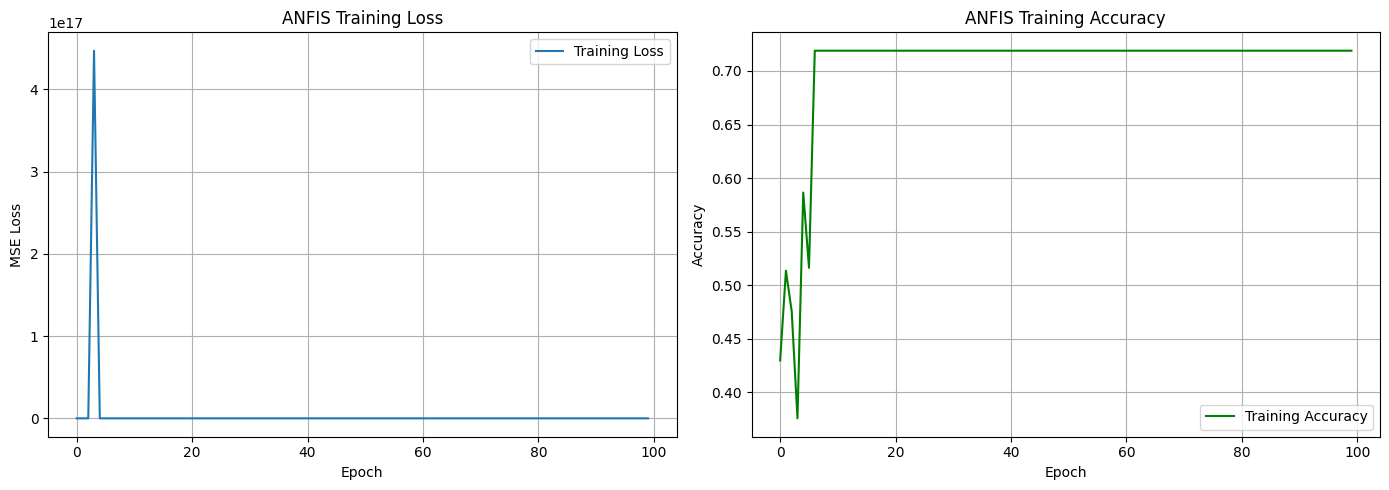


ANFIS EVALUATION ON TEST SET

Test Accuracy: 0.7328

Classification Report:
               precision    recall  f1-score   support

       Normal       0.67      0.12      0.21        33
Liver Disease       0.74      0.98      0.84        83

     accuracy                           0.73       116
    macro avg       0.70      0.55      0.52       116
 weighted avg       0.72      0.73      0.66       116



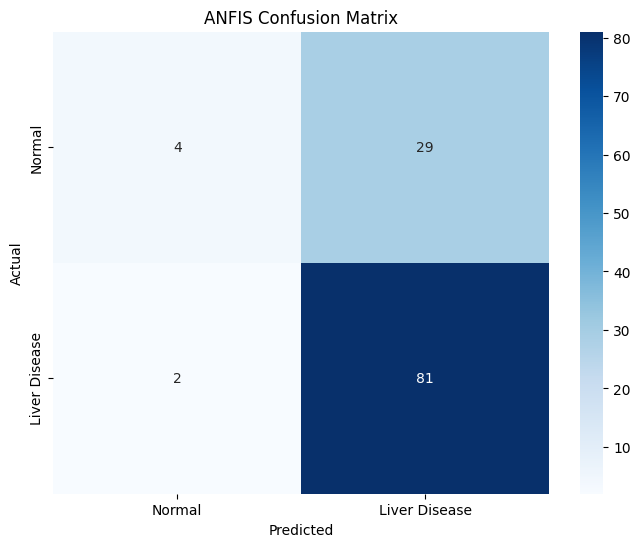

In [ ]:

# ADAPTIVE NEURO-FUZZY INFERENCE SYSTEM

print("ANFIS FOR LIVER DISEASE PREDICTION")

class ANFIS_LiverDisease:
    """
    ANFIS implementation for Liver Disease Prediction
    """
    def __init__(self, n_inputs=4, n_mfs=3, n_epochs=100, learning_rate=0.01):
        self.n_inputs = n_inputs
        self.n_mfs = n_mfs
        self.n_rules = n_mfs ** n_inputs
        self.n_epochs = n_epochs
        self.learning_rate = learning_rate

        # Initialize premise parameters (Gaussian MFs)
        self.premise_params = {
            'means': np.random.uniform(-2, 2, (n_inputs, n_mfs)),
            'sigmas': np.random.uniform(0.5, 1.5, (n_inputs, n_mfs))
        }

        # Initialize consequent parameters
        self.consequent_params = np.random.randn(self.n_rules, n_inputs + 1)

        # For tracking training history
        self.loss_history = []
        self.accuracy_history = []

    def gaussian_mf(self, x, mean, sigma):
        """Gaussian membership function"""
        return np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

    def forward_pass(self, X):
        """
        Forward pass through ANFIS
        X: Input data (n_samples, n_inputs)
        """
        n_samples = X.shape[0]

        # Layer 1: Fuzzification
        membership_values = np.zeros((n_samples, self.n_inputs, self.n_mfs))
        for i in range(self.n_inputs):
            for j in range(self.n_mfs):
                membership_values[:, i, j] = self.gaussian_mf(
                    X[:, i],
                    self.premise_params['means'][i, j],
                    self.premise_params['sigmas'][i, j]
                )

        # Layer 2: Rule firing strengths (using product T-norm)
        firing_strengths = np.ones((n_samples, self.n_rules))

        # Generate all combinations of MFs for rules
        from itertools import product
        mf_combinations = list(product(range(self.n_mfs), repeat=self.n_inputs))

        for r, combo in enumerate(mf_combinations):
            for i, mf_idx in enumerate(combo):
                firing_strengths[:, r] *= membership_values[:, i, mf_idx]

        # Layer 3: Normalize firing strengths
        sum_firing = np.sum(firing_strengths, axis=1, keepdims=True)
        normalized_firing = firing_strengths / (sum_firing + 1e-8)

        # Layer 4: Compute rule outputs (Takagi-Sugeno)
        rule_outputs = np.zeros((n_samples, self.n_rules))
        for r in range(self.n_rules):
            # Linear combination: a1*x1 + a2*x2 + ... + an*xn + c
            linear_comb = np.sum(
                [self.consequent_params[r, i] * X[:, i] for i in range(self.n_inputs)],
                axis=0
            ) + self.consequent_params[r, -1]
            rule_outputs[:, r] = linear_comb

        # Layer 5: Overall output
        output = np.sum(normalized_firing * rule_outputs, axis=1)

        return output, firing_strengths, normalized_firing, rule_outputs

    def backward_pass(self, X, y, output, normalized_firing, rule_outputs):
        """
        Backward pass for premise parameter updates
        """
        n_samples = X.shape[0]

        # Error
        error = output - y
        mse = np.mean(error ** 2)

        # Update premise parameters (simplified gradient descent)
        for i in range(self.n_inputs):
            for j in range(self.n_mfs):
                # Calculate gradient for mean
                grad_mean = np.zeros(n_samples)
                grad_sigma = np.zeros(n_samples)

                for r in range(self.n_rules):
                    # Simplified gradient (contribution of this MF to error)
                    grad_mean += error * normalized_firing[:, r]
                    grad_sigma += error * normalized_firing[:, r]

                # Update parameters
                self.premise_params['means'][i, j] -= self.learning_rate * np.mean(grad_mean)
                self.premise_params['sigmas'][i, j] -= self.learning_rate * np.mean(grad_sigma)
                # Keep sigma positive
                self.premise_params['sigmas'][i, j] = max(0.1, self.premise_params['sigmas'][i, j])

        return mse

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        """
        Train ANFIS with hybrid learning
        """
        n_samples = X.shape[0]

        for epoch in range(self.n_epochs):
            # Forward pass
            output, firing_strengths, normalized_firing, rule_outputs = self.forward_pass(X)

            # --- Hybrid Learning ---
            # Forward pass: Update consequent parameters using Least Squares
            H = np.zeros((n_samples, self.n_rules * (self.n_inputs + 1)))

            from itertools import product
            mf_combinations = list(product(range(self.n_mfs), repeat=self.n_inputs))

            for r in range(self.n_rules):
                # Create regressors for this rule: normalized_firing * [x1, x2, ..., xn, 1]
                rule_regressors = normalized_firing[:, r:r+1] * np.column_stack([X, np.ones(n_samples)])
                H[:, r*(self.n_inputs+1):(r+1)*(self.n_inputs+1)] = rule_regressors

            # Solve least squares
            try:
                theta = np.linalg.lstsq(H, y, rcond=None)[0]
                self.consequent_params = theta.reshape(self.n_rules, -1)
            except:
                pass

            # Backward pass: Update premise parameters using gradient descent
            train_loss = self.backward_pass(X, y, output, normalized_firing, rule_outputs)
            self.loss_history.append(train_loss)

            # Calculate accuracy
            predictions = (output > 0.5).astype(int)
            train_acc = accuracy_score(y, predictions)
            self.accuracy_history.append(train_acc)

            # Validation
            if X_val is not None and y_val is not None:
                val_output, _, _, _ = self.forward_pass(X_val)
                val_pred = (val_output > 0.5).astype(int)
                val_acc = accuracy_score(y_val, val_pred)
                val_loss = np.mean((val_output - y_val) ** 2)
            else:
                val_acc = None
                val_loss = None

            if verbose and epoch % 20 == 0:
                print(f"Epoch {epoch}: Train Loss={train_loss:.6f}, Train Acc={train_acc:.4f}",
                      end="")
                if val_acc is not None:
                    print(f", Val Loss={val_loss:.6f}, Val Acc={val_acc:.4f}")
                else:
                    print()

    def predict(self, X, threshold=0.5):
        """Make predictions"""
        output, _, _, _ = self.forward_pass(X)
        return (output > threshold).astype(int), output

    def predict_proba(self, X):
        """Get prediction probabilities"""
        output, _, _, _ = self.forward_pass(X)
        return np.column_stack([1-output, output])

# Prepare data for ANFIS (using selected features)
selected_features_idx = [0, 1, 4, 6]  # Age, Total Bilirubin, Alkaline Phosphatase, Albumin
X_train_anfis = X_train_scaled[:, selected_features_idx]
X_test_anfis = X_test_scaled[:, selected_features_idx]

# Split training data for validation
X_train_anfis, X_val_anfis, y_train_anfis, y_val_anfis = train_test_split(
    X_train_anfis, y_train, test_size=0.2, random_state=42
)

print(f"\nANFIS Training Data Shape: {X_train_anfis.shape}")
print(f"ANFIS Validation Data Shape: {X_val_anfis.shape}")
print(f"ANFIS Test Data Shape: {X_test_anfis.shape}")

# Create and train ANFIS
print("\nTraining ANFIS model...")
anfis = ANFIS_LiverDisease(
    n_inputs=4,  # 4 features
    n_mfs=3,     # 3 membership functions per input
    n_epochs=100,
    learning_rate=0.01
)

anfis.fit(X_train_anfis, y_train_anfis, X_val_anfis, y_val_anfis, verbose=True)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(anfis.loss_history, label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('ANFIS Training Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(anfis.accuracy_history, label='Training Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ANFIS Training Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate ANFIS on test set
print("\n" + "="*70)
print("ANFIS EVALUATION ON TEST SET")
print("="*70)

y_pred_anfis, y_scores_anfis = anfis.predict(X_test_anfis)
test_accuracy = accuracy_score(y_test, y_pred_anfis)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_anfis, target_names=['Normal', 'Liver Disease']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_anfis)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Liver Disease'],
            yticklabels=['Normal', 'Liver Disease'])
plt.title('ANFIS Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Compare FIS and ANFIS Performance**


COMPARISON: FIS vs ANFIS PERFORMANCE

Model Performance Comparison:
Model                Accuracy        Precision       Recall          F1-Score       
FIS (Rule-based)     0.7155          0.5120          0.7155          0.5969         
ANFIS (Neuro-Fuzzy)  0.7328          0.7165          0.7328          0.6589         


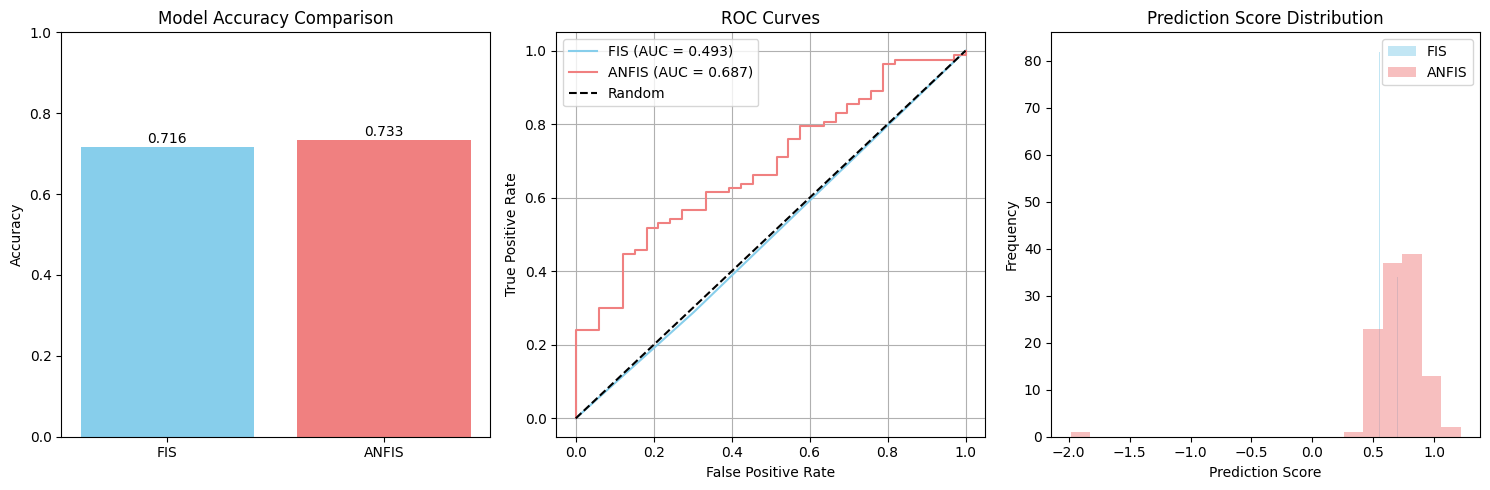


FEATURE IMPORTANCE ANALYSIS


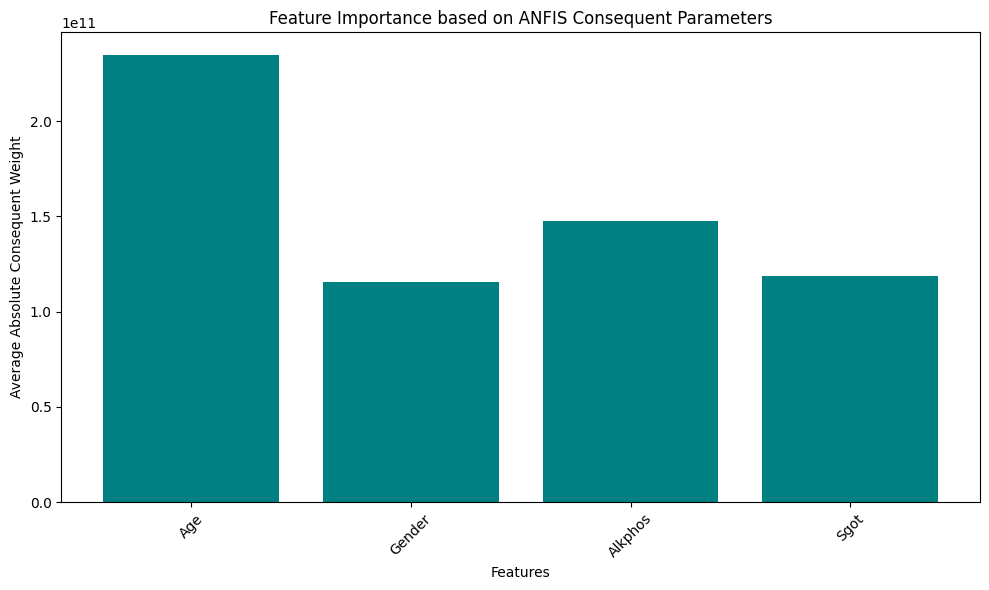


Feature Importance Rankings:
  Age: 234878197473.5529
  Alkphos: 147422499519.4536
  Sgot: 118505599958.3214
  Gender: 115305731701.9234


In [ ]:

# COMPARISON: FIS vs ANFIS

print("COMPARISON: FIS vs ANFIS PERFORMANCE")

# Evaluate FIS on test set
fis_predictions = []
fis_scores = []

for i in range(len(X_test)):
    patient_data = X_test[i]

    # Denormalize for FIS
    age_val = patient_data[0] * scaler.scale_[0] + scaler.mean_[0]
    tb_val = patient_data[1] * scaler.scale_[1] + scaler.mean_[1]
    alp_val = patient_data[4] * scaler.scale_[4] + scaler.mean_[4]
    alb_val = patient_data[6] * scaler.scale_[6] + scaler.mean_[6]

    try:
        liver_simulation.input['age'] = age_val
        liver_simulation.input['total_bilirubin'] = abs(tb_val)
        liver_simulation.input['alkaline_phosphatase'] = abs(alp_val)
        liver_simulation.input['albumin'] = abs(alb_val)

        liver_simulation.compute()

        risk_score = liver_simulation.output['liver_risk']
        prediction = 1 if risk_score > 50 else 0

        fis_predictions.append(prediction)
        fis_scores.append(risk_score / 100)  # Normalize to 0-1
    except:
        # If FIS fails, use default prediction (majority class)
        fis_predictions.append(1)  # Default to liver disease
        fis_scores.append(0.7)

# Calculate FIS accuracy
fis_accuracy = accuracy_score(y_test[:len(fis_predictions)], fis_predictions)

print("\nModel Performance Comparison:")

print(f"{'Model':<20} {'Accuracy':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")


from sklearn.metrics import precision_score, recall_score, f1_score

# FIS Metrics
fis_precision = precision_score(y_test[:len(fis_predictions)], fis_predictions, average='weighted')
fis_recall = recall_score(y_test[:len(fis_predictions)], fis_predictions, average='weighted')
fis_f1 = f1_score(y_test[:len(fis_predictions)], fis_predictions, average='weighted')

print(f"{'FIS (Rule-based)':<20} {fis_accuracy:<15.4f} {fis_precision:<15.4f} {fis_recall:<15.4f} {fis_f1:<15.4f}")

# ANFIS Metrics
anfis_precision = precision_score(y_test, y_pred_anfis, average='weighted')
anfis_recall = recall_score(y_test, y_pred_anfis, average='weighted')
anfis_f1 = f1_score(y_test, y_pred_anfis, average='weighted')

print(f"{'ANFIS (Neuro-Fuzzy)':<20} {test_accuracy:<15.4f} {anfis_precision:<15.4f} {anfis_recall:<15.4f} {anfis_f1:<15.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy comparison
models = ['FIS', 'ANFIS']
accuracies = [fis_accuracy, test_accuracy]
colors = ['skyblue', 'lightcoral']
axes[0].bar(models, accuracies, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# ROC Curves
from sklearn.metrics import roc_curve, auc

# FIS ROC (approximated)
fis_fpr, fis_tpr, _ = roc_curve(y_test[:len(fis_scores)], fis_scores)
fis_auc = auc(fis_fpr, fis_tpr)

# ANFIS ROC
anfis_fpr, anfis_tpr, _ = roc_curve(y_test, y_scores_anfis)
anfis_auc = auc(anfis_fpr, anfis_tpr)

axes[1].plot(fis_fpr, fis_tpr, label=f'FIS (AUC = {fis_auc:.3f})', color='skyblue')
axes[1].plot(anfis_fpr, anfis_tpr, label=f'ANFIS (AUC = {anfis_auc:.3f})', color='lightcoral')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()
axes[1].grid(True)

# Prediction distribution
axes[2].hist(fis_scores, alpha=0.5, label='FIS', bins=20, color='skyblue')
axes[2].hist(y_scores_anfis, alpha=0.5, label='ANFIS', bins=20, color='lightcoral')
axes[2].set_xlabel('Prediction Score')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Prediction Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

# Feature Importance Analysis (using ANFIS consequent parameters)
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Analyze consequent parameters to infer feature importance
feature_importance = np.abs(anfis.consequent_params[:, :4]).mean(axis=0)
feature_names_selected = [feature_names[i] for i in selected_features_idx]

plt.figure(figsize=(10, 6))
plt.bar(feature_names_selected, feature_importance, color='teal')
plt.xlabel('Features')
plt.ylabel('Average Absolute Consequent Weight')
plt.title('Feature Importance based on ANFIS Consequent Parameters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
for name, importance in sorted(zip(feature_names_selected, feature_importance),
                                key=lambda x: x[1], reverse=True):
    print(f"  {name}: {importance:.4f}")

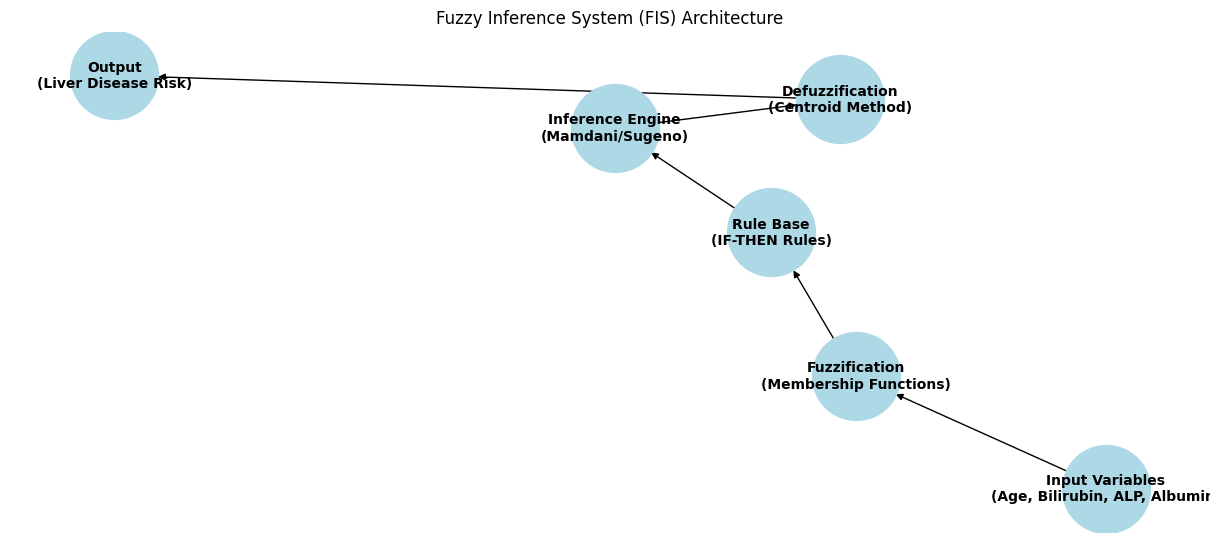

In [ ]:
# FIS layer architecture diagram

# Create directed graph
G = nx.DiGraph()

# Nodes of FIS
nodes = [
    "Input Variables\n(Age, Bilirubin, ALP, Albumin)",
    "Fuzzification\n(Membership Functions)",
    "Rule Base\n(IF-THEN Rules)",
    "Inference Engine\n(Mamdani/Sugeno)",
    "Defuzzification\n(Centroid Method)",
    "Output\n(Liver Disease Risk)"
]

# Add nodes
for node in nodes:
    G.add_node(node)

# Add edges
edges = [
    (nodes[0], nodes[1]),
    (nodes[1], nodes[2]),
    (nodes[2], nodes[3]),
    (nodes[3], nodes[4]),
    (nodes[4], nodes[5])
]

G.add_edges_from(edges)

# Draw
plt.figure(figsize=(12,5))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightblue",
    node_size=4000,
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("Fuzzy Inference System (FIS) Architecture")
plt.show()


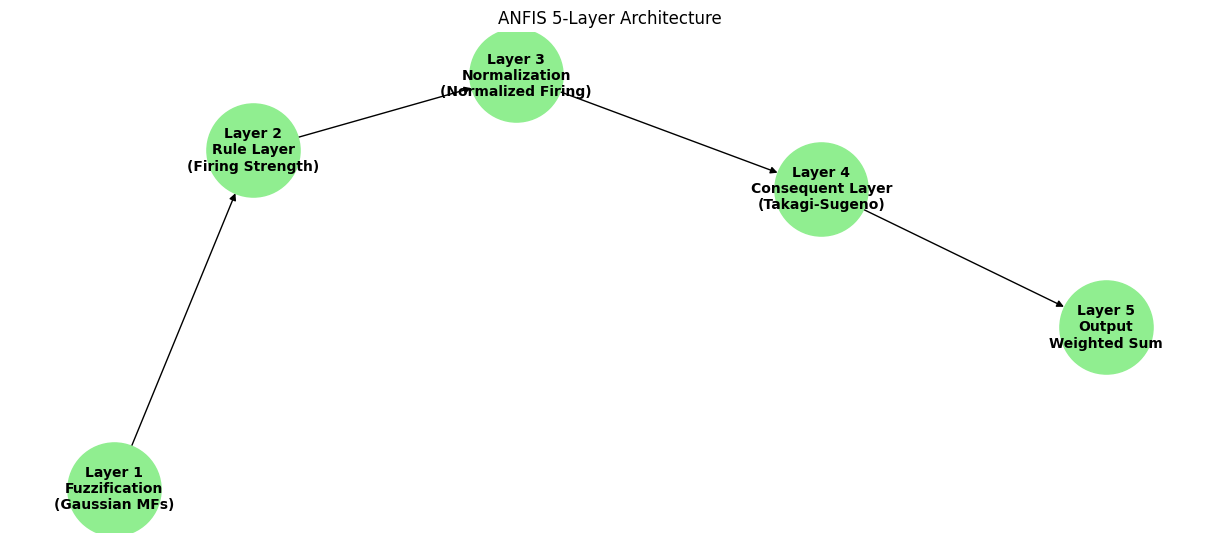

In [ ]:
# AFNIS

G = nx.DiGraph()

layers = [
    "Layer 1\nFuzzification\n(Gaussian MFs)",
    "Layer 2\nRule Layer\n(Firing Strength)",
    "Layer 3\nNormalization\n(Normalized Firing)",
    "Layer 4\nConsequent Layer\n(Takagi-Sugeno)",
    "Layer 5\nOutput\nWeighted Sum"
]

for layer in layers:
    G.add_node(layer)

edges = [
    (layers[0], layers[1]),
    (layers[1], layers[2]),
    (layers[2], layers[3]),
    (layers[3], layers[4])
]

G.add_edges_from(edges)

plt.figure(figsize=(12,5))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=4500,
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("ANFIS 5-Layer Architecture")
plt.show()

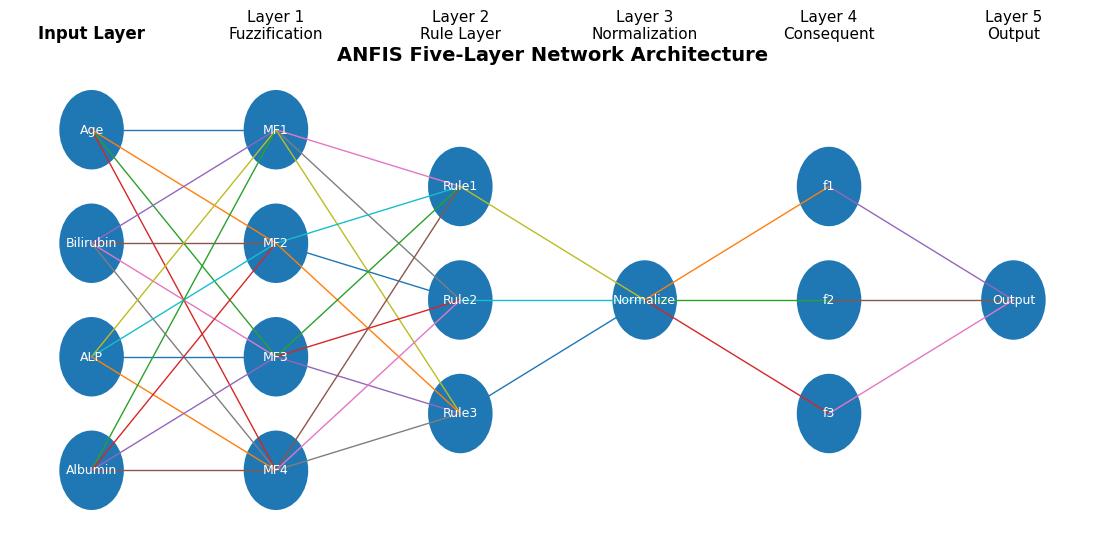

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Node positions (x,y)
nodes = {
    "Age":(0,3),
    "Bilirubin":(0,2),
    "ALP":(0,1),
    "Albumin":(0,0),

    "MF1":(2,3),
    "MF2":(2,2),
    "MF3":(2,1),
    "MF4":(2,0),

    "Rule1":(4,2.5),
    "Rule2":(4,1.5),
    "Rule3":(4,0.5),

    "Normalize":(6,1.5),

    "f1":(8,2.5),
    "f2":(8,1.5),
    "f3":(8,0.5),

    "Output":(10,1.5)
}

# Draw nodes
for name,(x,y) in nodes.items():
    circle = plt.Circle((x,y),0.35)
    plt.gca().add_patch(circle)
    plt.text(x,y,name,ha='center',va='center',color="white",fontsize=9)

# Function to draw connection
def connect(a,b):
    x1,y1 = nodes[a]
    x2,y2 = nodes[b]
    plt.plot([x1,x2],[y1,y2],linewidth=1)

# Input → MF
for inp in ["Age","Bilirubin","ALP","Albumin"]:
    for mf in ["MF1","MF2","MF3","MF4"]:
        connect(inp,mf)

# MF → Rules
for mf in ["MF1","MF2","MF3","MF4"]:
    for rule in ["Rule1","Rule2","Rule3"]:
        connect(mf,rule)

# Rules → Normalize
for rule in ["Rule1","Rule2","Rule3"]:
    connect(rule,"Normalize")

# Normalize → Consequent
for f in ["f1","f2","f3"]:
    connect("Normalize",f)

# Consequent → Output
for f in ["f1","f2","f3"]:
    connect(f,"Output")

# Layer titles
plt.text(0,3.8,"Input Layer",fontsize=12,fontweight="bold",ha="center")
plt.text(2,3.8,"Layer 1\nFuzzification",fontsize=11,ha="center")
plt.text(4,3.8,"Layer 2\nRule Layer",fontsize=11,ha="center")
plt.text(6,3.8,"Layer 3\nNormalization",fontsize=11,ha="center")
plt.text(8,3.8,"Layer 4\nConsequent",fontsize=11,ha="center")
plt.text(10,3.8,"Layer 5\nOutput",fontsize=11,ha="center")

plt.title("ANFIS Five-Layer Network Architecture",fontsize=14,fontweight="bold")
plt.axis("off")
plt.show()